<a href="https://colab.research.google.com/github/tayaland1514/statprak_hw/blob/main/hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Serial test

Idea: break the sequence $x_1, x_2, x_3, ..., x_{2n}$ into consecutive series of length $2$: $(x_1, x_2), (x_3, x_4), ..., (x_{2n-1}, x_{2n})$ and look at each element as a random and independent point in $2D$ space. Next, apply chi-square. Similarly, one can construct series of length $3, 4$, etc.

### Problem 1
Implement serial test and apply to a `samples`

In [ ]:
import numpy as np
from scipy import stats

In [ ]:
# берем lcg генератор из ноутбука
def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

In [ ]:
# генерируем samples как в ноутбуке
samples = [rng() for _ in range(1000)]

In [ ]:
def serial_test(samples, bins=10):
    n = len(samples) // 2 * 2
    pairs = np.array([samples[:n:2], samples[1:n:2]]).T
    observed, _, _ = np.histogram2d(pairs[:, 0], pairs[:, 1], bins=bins)
    observed = observed.flatten()
    expected = np.full(bins*bins, n//2 / (bins*bins))
    chi2_stat, p_value = stats.chisquare(observed, expected)
    return chi2_stat, p_value

chi2, p = serial_test(samples)
print(f"chi-square statistic = {chi2:.4f}")
print(f"p-value = {p:.4f}")

chi-square statistic = 100.4000
p-value = 0.4418


### Permutation test

We again decompose the sequence $x_1, x_2, x_3, ..., x_{dn}$ into consecutive series of length $d$: $(x_1, ..., x_d), (x_{d+1}, x_{2d+d}), \ldots, (x_{nd-d+1}, x_{nd})$. A series of $d$ elements can be ordered in $d!$ ways and each way of ordering is equally probable. Hence the idea of the test is to count how many times each ordering occurs among $n$ series and apply the $\chi^2$ test.

### Problem 2*
Implement permutation test and apply to a `samples`

In [ ]:
from itertools import permutations

In [ ]:
def permutation_test(samples, d=3):
    n = len(samples) // d * d
    sequences = np.array([samples[i:i+d] for i in range(0, n, d)])
    all_permutations = list(permutations(range(d)))
    perm_counts = {perm: 0 for perm in all_permutations}

    for seq in sequences:
        perm = tuple(np.argsort(seq))
        if perm in perm_counts:
            perm_counts[perm] += 1

    observed = np.array(list(perm_counts.values()))
    expected = np.full(len(all_permutations), n/d / len(all_permutations))
    chi2_stat, p_value = stats.chisquare(observed, expected)
    return chi2_stat, p_value

chi2, p = permutation_test(samples)
print(f"chi-square statistic = {chi2:.4f}")
print(f"p-value = {p:.4f}")

chi-square statistic = 4.8559
p-value = 0.4337


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

сравнение генераторов:

хороший RNG
тест Колмогорова-Смирнова: p-value = 0.1036 - ok
хи-квадрат тест: p-value = 0.2171 - ok
serial тест: p-value = 0.6181 - ok

плохой RNG
тест Колмогорова-Смирнова: p-value = 0.0987 - ok
хи-квадрат тест: p-value = 0.4443 - ok
serial тест: p-value = 0.0472 - not ok


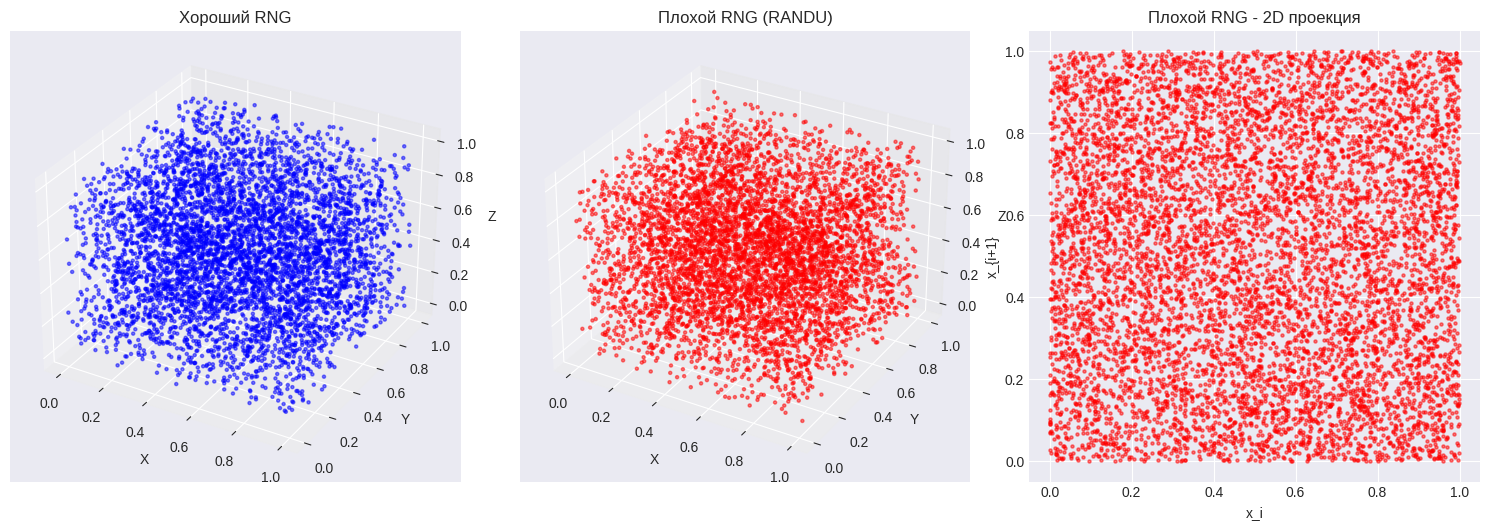

In [ ]:
def test_rng_quality(rng_func, name, n_samples=800000):
    samples = [rng_func() for i in range(n_samples)]
    print(f"\n{name}")

    ks_stat, ks_p = stats.kstest(samples, stats.uniform.cdf)
    print(f"тест Колмогорова-Смирнова: p-value = {ks_p:.4f} - {'ok' if ks_p > 0.05 else 'not ok'}")

    hist, _ = np.histogram(samples, bins=20)
    expected = np.full(20, n_samples/20)
    chi2_stat, chi2_p = stats.chisquare(hist, expected)
    print(f"хи-квадрат тест: p-value = {chi2_p:.4f} - {'ok' if chi2_p > 0.05 else 'not ok'}")

    serial_stat, serial_p = serial_test(samples)
    print(f"serial тест: p-value = {serial_p:.4f} - {'ok' if serial_p > 0.05 else 'not ok'}")

    return samples

print("сравнение генераторов:")
samples_good = test_rng_quality(rng, "хороший RNG")
samples_bad = test_rng_quality(rng_bad, "плохой RNG")

'''
я буду брать каждый 50-й эл-т, тк то, что rng_bad хуже, видно только начиная где-то с 500000
(я беру 800к в итоге), а на графике 500к точек отображаются как-то не хайпово, так что step = 50
'''
step = 50

samples_good_sparse = samples_good[::step]
n_good = len(samples_good_sparse) // 3 * 3
samples_good_sparse = samples_good_sparse[:n_good]
samples_bad_sparse = samples_bad[::step]
n_bad = len(samples_bad_sparse) // 3 * 3
samples_bad_sparse = samples_bad_sparse[:n_bad]
samples_bad_sparse_2d = samples_bad[::step]
n_bad_2d = len(samples_bad_sparse_2d) // 2 * 2
samples_bad_sparse_2d = samples_bad_sparse_2d[:n_bad_2d]

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(samples_good_sparse[::3],
            samples_good_sparse[1::3],
            samples_good_sparse[2::3],
            s=5, alpha=0.5, c='blue')
ax1.set_title('Хороший RNG')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(samples_bad_sparse[::3],
            samples_bad_sparse[1::3],
            samples_bad_sparse[2::3],
            s=5, alpha=0.5, c='red')
ax2.set_title('Плохой RNG (RANDU)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax3 = fig.add_subplot(133)
ax3.scatter(samples_bad_sparse_2d[::2],
            samples_bad_sparse_2d[1::2],
            s=5, alpha=0.5, c='red')
ax3.set_title('Плохой RNG - 2D проекция')
ax3.set_xlabel('x_i')
ax3.set_ylabel('x_{i+1}')
ax3.set_aspect('equal')

plt.tight_layout()
plt.show()

### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

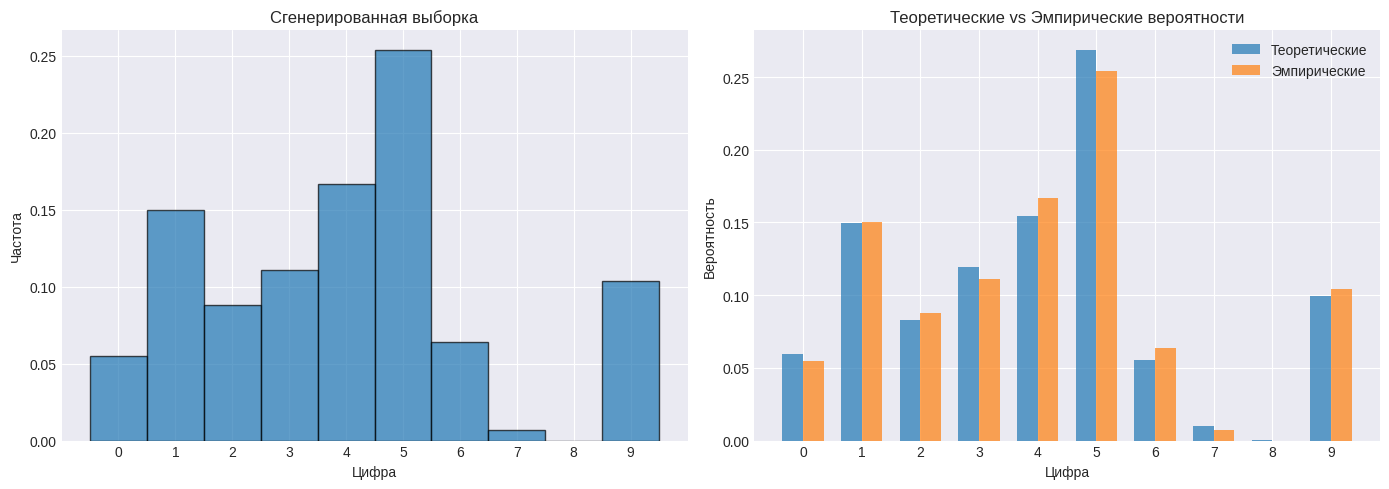


Максимальное отклонение: 0.0148


In [ ]:
digits = np.arange(10)
weights = [0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2]
sort_idx = np.argsort(weights)[::-1]
weights_sorted = np.array(weights)[sort_idx]
digits_sorted = digits[sort_idx]
probs = weights_sorted / weights_sorted.sum()
sums = np.cumsum(probs)
n_samples = 1000
u = np.random.rand(n_samples)
samples = [digits_sorted[np.searchsorted(sums, i)] for i in u]
samples = np.array(samples)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(samples, bins=np.arange(-0.5, 10.5, 1), density=True, alpha=0.7, edgecolor='black')
ax1.set_title('Сгенерированная выборка')
ax1.set_xlabel('Цифра')
ax1.set_ylabel('Частота')
ax1.set_xticks(digits)

theoretical = np.array(weights) / np.sum(weights)
empirical = np.bincount(samples, minlength=10) / n_samples

x = np.arange(10)
width = 0.35
ax2.bar(x - width/2, theoretical, width, label='Теоретические', alpha=0.7)
ax2.bar(x + width/2, empirical, width, label='Эмпирические', alpha=0.7)
ax2.set_title('Теоретические vs Эмпирические вероятности')
ax2.set_xlabel('Цифра')
ax2.set_ylabel('Вероятность')
ax2.legend()
ax2.set_xticks(x)
plt.tight_layout()
plt.show()
print(f"\nМаксимальное отклонение: {np.max(np.abs(theoretical - empirical)):.4f}")

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

In [ ]:
from scipy import stats

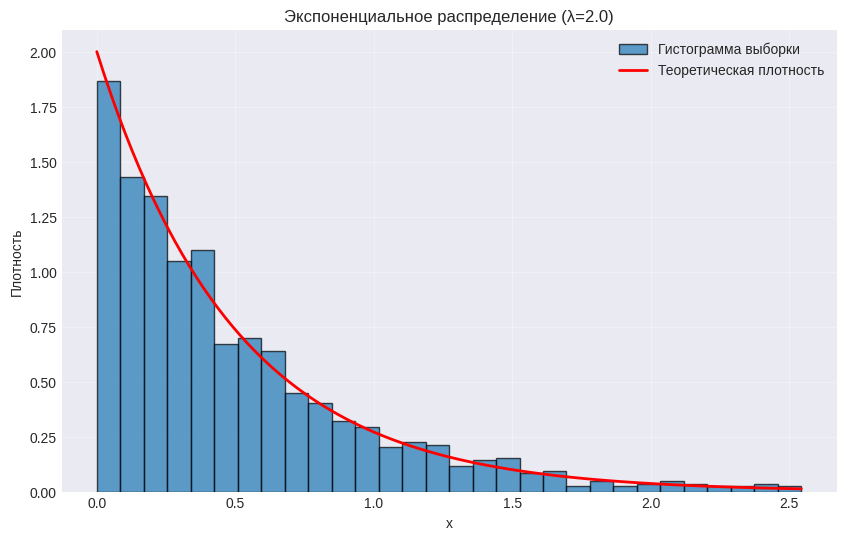

In [ ]:
lambda_param = 2.0
n_samples = 1000
u = np.random.rand(n_samples)
samples = -np.log(u) / lambda_param

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=30, density=True, alpha=0.7, label='Гистограмма выборки', edgecolor='black')
x = np.linspace(0, max(samples), 100)
pdf = lambda_param * np.exp(-lambda_param * x)
plt.plot(x, pdf, 'r-', linewidth=2, label='Теоретическая плотность')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(f'Экспоненциальное распределение (λ={lambda_param})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

In [ ]:
from scipy import integrate
import math

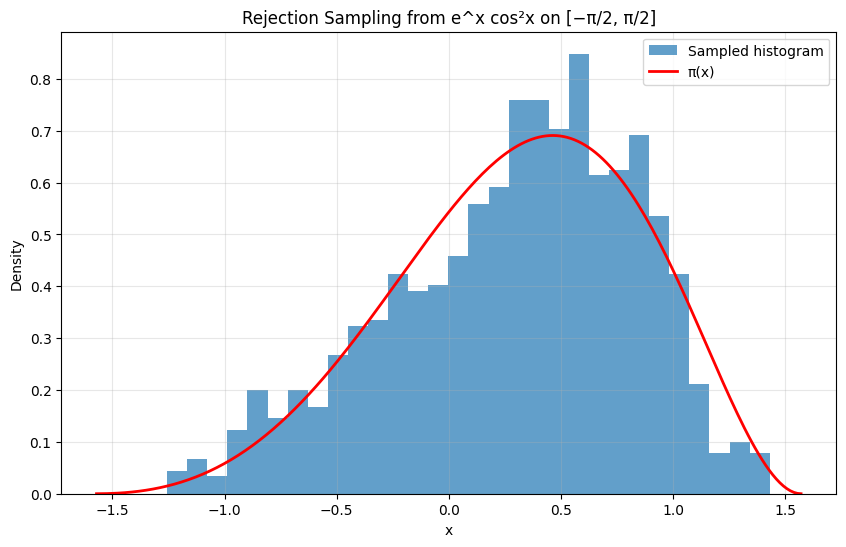

In [ ]:
a, b = -np.pi/2, np.pi/2

def g(x):
    return np.exp(x) * np.cos(x)**2

# вычисляем нормировочную константу Z
Z, error = integrate.quad(g, a, b)

def target_pdf(x):
    return g(x) / Z

def uniform_pdf(x):
    return 1 / (b - a)

def sample_proposal(n):
    return np.random.uniform(a, b, n)

def rejection_sample(M, n_samples):
    samples = []
    n_trials = 0
    while len(samples) < n_samples:
        n_trials += 1
        x = sample_proposal(1)[0]
        u = np.random.uniform(0, M * uniform_pdf(x))
        if u <= target_pdf(x):
            samples.append(x)
    acceptance_rate = n_samples / n_trials
    return np.array(samples)

x_test = np.linspace(a, b, 1000)
max_target = max(target_pdf(x_test))
M_needed = max_target * (b - a)
M = math.ceil(M_needed * 100) / 100  # округление до сотых вверх

np.random.seed(42)
samples = rejection_sample(M, 1000)

x_plot = np.linspace(a, b, 200)
pdf_plot = target_pdf(x_plot)
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=30, density=True, alpha=0.7, label='Sampled histogram')
plt.plot(x_plot, pdf_plot, 'r-', linewidth=2, label='π(x)')
plt.xlabel('x')
plt.ylabel('Density')
plt.title(f'Rejection Sampling from e^x cos²x on [−π/2, π/2]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Coordinate transformation method

The accept-reject method may in some cases be inefficient and require too many sample points. An alternative is to try to find a coordinate transformation that converts a simple area (from which it is easy to sample, for example, a unit square) into the required area, but preserves the area ratio (why?).

Если $(u,v)$ — координаты в $S$ с плотностью $p_S(u,v) = 1$ (равномерное распр-е)

После преобразования $(x,y) = \phi(u,v)$ плотность будет

$$
p(x,y) = \frac{p_S(u,v)}{|J(u,v)|} = \frac{1}{|J(u,v)|}
$$

($J$ — якобиан)

Чтобы $p(x,y)$ была константой (равномерное распр-е), нужно, чтобы $|J(u,v)|$ был константой, и если $|J| =$ константа, то преобразование изменяет все площади в одинаковое кол-во раз, тогда распр-е тоже будет равномерным, просто с другой плотностью (которую можно потом нормировать)

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

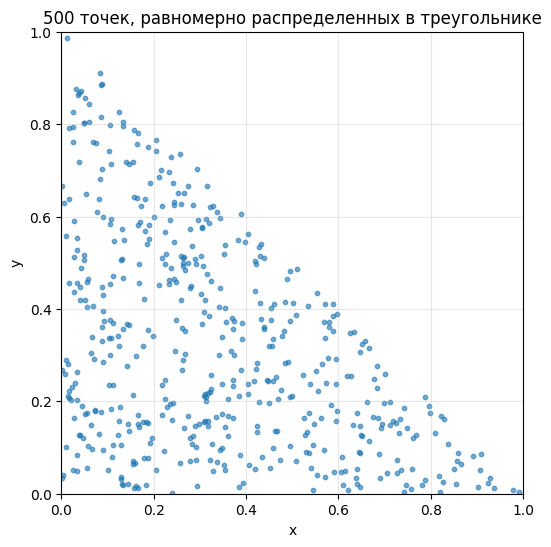

In [ ]:
n_points = 500
u = np.random.uniform(0, 1, n_points)
v = np.random.uniform(0, 1, n_points)

'''
Рассм преобразование, переводящее единичный квадрат [0,1]×[0,1] в треугольник с вершинами A = (0,0), B = (1,0), C = (0,1)
Если u,v∼U[0,1] точки в этом квадрате, то:
Если u + v > 1, заменяем: u = 1 − u,v = 1 − v - это отражает точки из верхнего правого треугольника в нижний левый
Тогда точка в треугольнике: P = A + u⋅(B − A) + v⋅(C − A)'''
mask = u + v > 1
u[mask] = 1 - u[mask]
v[mask] = 1 - v[mask]

# координаты в треугольнике
x = u
y = v

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6, s=10)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('500 точек, равномерно распределенных в треугольнике')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

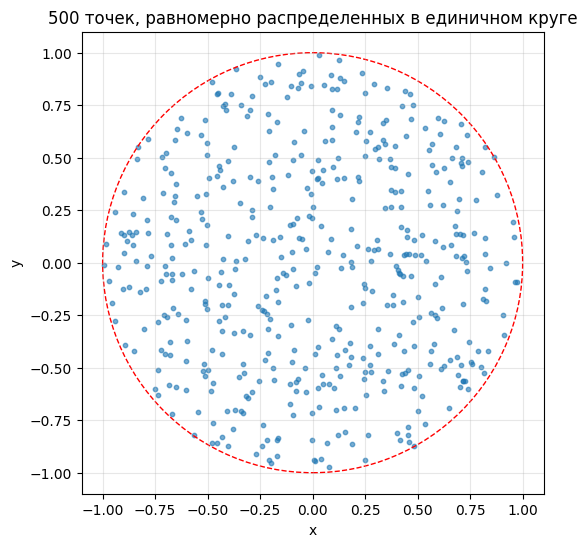

In [ ]:
n_points = 500

# равномерное u для радиуса и равномерное theta
u = np.random.uniform(0, 1, n_points)
theta = np.random.uniform(0, 2*np.pi, n_points)

# преобразование для равномерного распределения по площади
r = np.sqrt(u)

# декартовы координаты
x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6, s=10)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('500 точек, равномерно распределенных в единичном круге')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
plt.gca().add_artist(circle)
plt.show()

# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [5]:
import seaborn as sns
from scipy.linalg import cholesky
import numpy as np
import matplotlib.pyplot as plt

Точное среднее: [4 7]
Выборочное среднее: [4.19975974 7.07067994]
Точная ковариационная матрица:
  20.0    -4.0
  -4.0    40.0
Выборочная ковариационная матрица:
  19.5    -3.7
  -3.7    43.0


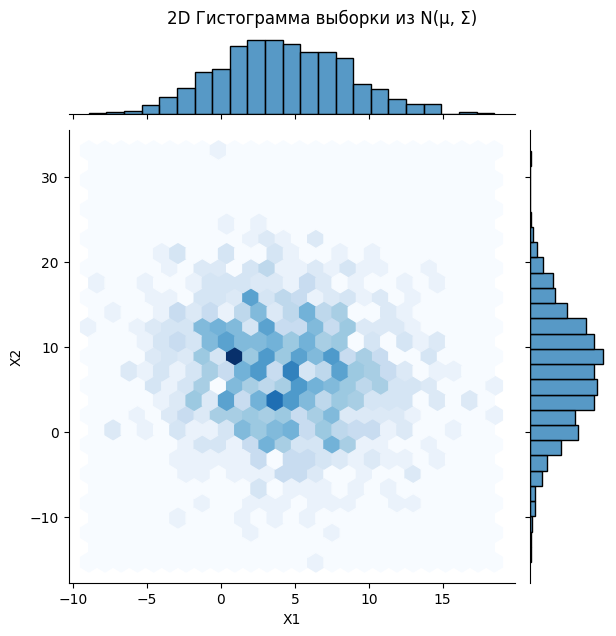

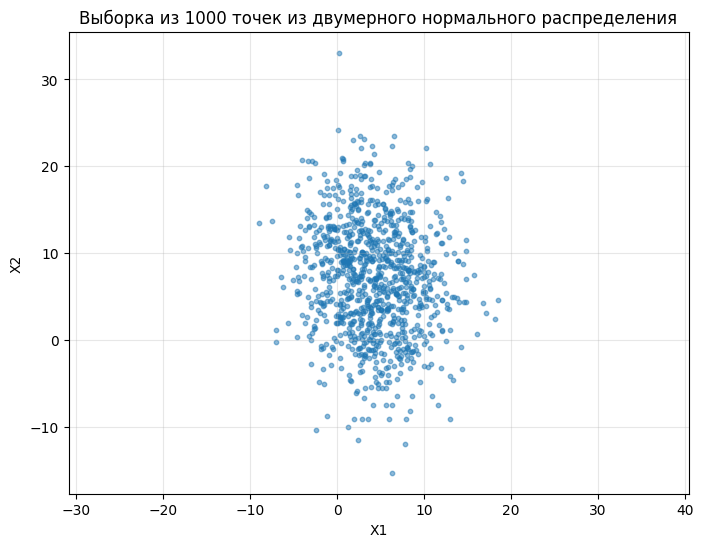

In [8]:
def box_muller_polar(n):
    z = np.zeros((n, 2))
    for i in range(n):
        while True:
            u = 2 * np.random.rand() - 1  # U(-1, 1)
            v = 2 * np.random.rand() - 1  # U(-1, 1)
            s = u**2 + v**2
            if 0 < s < 1:
                break
        c = np.sqrt(-2 * np.log(s) / s)
        z[i, 0] = u * c
        z[i, 1] = v * c
    return z

# параметры распределения
mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])
n_samples = 1000

# 1. генерируем стандартные нормальные величины
Z = box_muller_polar(n_samples)

# 2. вычисляем разложение Холецкого
L = cholesky(Sigma, lower=True)  # L - нижняя треугольная матрица

# 3. трансформируем в требуемое распределение
X = mu + Z @ L.T  # X = mu + Z * L^T

# 4. анализ результатов
sample_mean = np.mean(X, axis=0)
sample_cov = np.cov(X, rowvar=False)

print("Точное среднее:", mu)
print("Выборочное среднее:", sample_mean)
print("Точная ковариационная матрица:")
for i in range(Sigma.shape[0]):
    row = "  ".join(f"{Sigma[i, j]:6.1f}" for j in range(Sigma.shape[1]))
    print(row)
print("Выборочная ковариационная матрица:")
for i in range(sample_cov.shape[0]):
    row = "  ".join(f"{sample_cov[i, j]:6.1f}" for j in range(sample_cov.shape[1]))
    print(row)

joint_plot = sns.jointplot(x=X[:, 0], y=X[:, 1], kind='hex', bins=30, cmap='Blues')
joint_plot.set_axis_labels('X1', 'X2')
plt.suptitle('2D Гистограмма выборки из N(μ, Σ)', y=1.02)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, s=10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Выборка из 1000 точек из двумерного нормального распределения')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()